# 04 · Autoencoder con PyTorch

**Objetivo del notebook:** comparar el modelo supervisado con un detector no supervisado que no necesita etiquetas de fraude, y revisar si ambos encuentran los mismos casos.

El autoencoder se entrena solo con transacciones legítimas del periodo de entrenamiento, de modo que aprende a reconstruir el comportamiento normal; una transacción que reconstruye mal se aleja de ese comportamiento y recibe un puntaje de anomalía alto.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import precision_recall_curve
from fraude import autoencoder as ae, base_datos as bd, config, datos, graficos, modelo
graficos.estilo()
print(f"PyTorch {torch.__version__}")

PyTorch 2.14.1+cu130


# Carga de datos y del modelo supervisado

In [2]:
# El paquete guardado en el notebook 03 trae el pipeline ya ajustado,
# los cortes temporales y las columnas, de modo que las particiones son idénticas

paquete = modelo.cargar('modelo_lightgbm.joblib')
cortes = paquete['cortes']

conn = bd.conectar()
df = datos.cargar_datos(conn, paquete['columnas']['transacciones'], paquete['columnas']['identidad'])
conn.close()

df_train, df_valid, df_test = datos.particion_cronologica(df, cortes)
excluir_siempre = [config.ID, config.OBJETIVO]

X_train_proc = paquete['pipeline'].transform(df_train.drop(columns=excluir_siempre))
X_valid_proc = paquete['pipeline'].transform(df_valid.drop(columns=excluir_siempre))
X_test_proc = paquete['pipeline'].transform(df_test.drop(columns=excluir_siempre))
y_train, y_valid, y_test = (p['isFraud'].values for p in (df_train, df_valid, df_test))

print(f"Train: {X_train_proc.shape} | Valid: {X_valid_proc.shape} | Test: {X_test_proc.shape}")
print(f"Legítimas para entrenar el autoencoder: {(y_train == 0).sum():,}")
print(f"Fraudes etiquetados con los que aprendió LightGBM (Train + Valid): {y_train.sum() + y_valid.sum():,}")

Train: (354324, 212) | Valid: (118108, 212) | Test: (118108, 212)
Legítimas para entrenar el autoencoder: 342,336
Fraudes etiquetados con los que aprendió LightGBM (Train + Valid): 16,599


# Preparación de la entrada

In [3]:
# Estandarización ajustada solo con las legítimas de Train y recorte a ±5
# desviaciones, para que unos pocos valores extremos no dominen el error

escalador = ae.Escalador().fit(X_train_proc[y_train == 0])
Z_train_leg = escalador.transform(X_train_proc[y_train == 0])
Z_valid_leg = escalador.transform(X_valid_proc[y_valid == 0])
Z_test = escalador.transform(X_test_proc)

print(f"Entrada del autoencoder: {Z_train_leg.shape[1]} variables")
print(f"Valores recortados en Train: {(np.abs(Z_train_leg) == ae.LIMITE).mean()*100:.2f}%")

Entrada del autoencoder: 212 variables


Valores recortados en Train: 0.40%


# Entrenamiento

 epoca  entrenamiento  validacion
     1         0.2505      0.1893
     2         0.1563      0.1696
     3         0.1443      0.1617
     4         0.1383      0.1569
     5         0.1345      0.1534
     6         0.1315      0.1503
     7         0.1290      0.1475
     8         0.1269      0.1449
     9         0.1249      0.1430
    10         0.1230      0.1408
    11         0.1210      0.1380
    12         0.1192      0.1363
    13         0.1177      0.1351
    14         0.1165      0.1337
    15         0.1153      0.1326


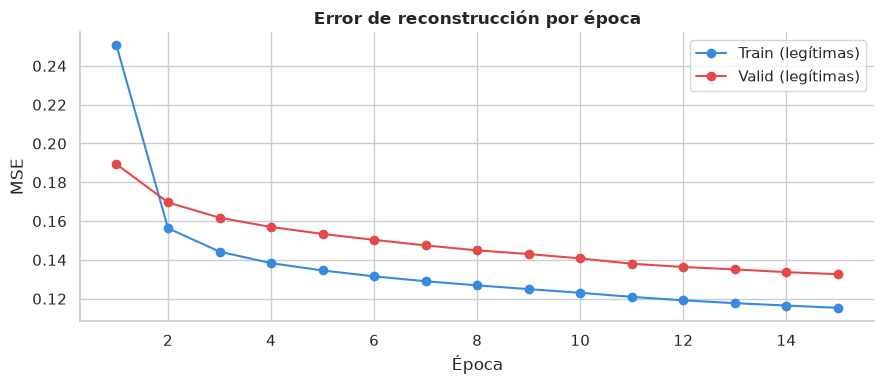

In [4]:
# Arquitectura: entrada → 64 → 16 → 64 → entrada, pérdida MSE y optimizador Adam

red, historial = ae.entrenar(Z_train_leg, Z_valid_leg, epocas=15)
historial = pd.DataFrame(historial)
print(historial.round(4).to_string(index=False))

fig = plt.figure(figsize=(9, 4))
plt.plot(historial['epoca'], historial['entrenamiento'], marker='o', color=graficos.AZUL, label='Train (legítimas)')
plt.plot(historial['epoca'], historial['validacion'], marker='o', color=graficos.ROJO, label='Valid (legítimas)')
plt.title('Error de reconstrucción por época')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()
sns.despine()
plt.tight_layout()
graficos.guardar(fig, '04_entrenamiento')
plt.show()

# Error de reconstrucción por clase

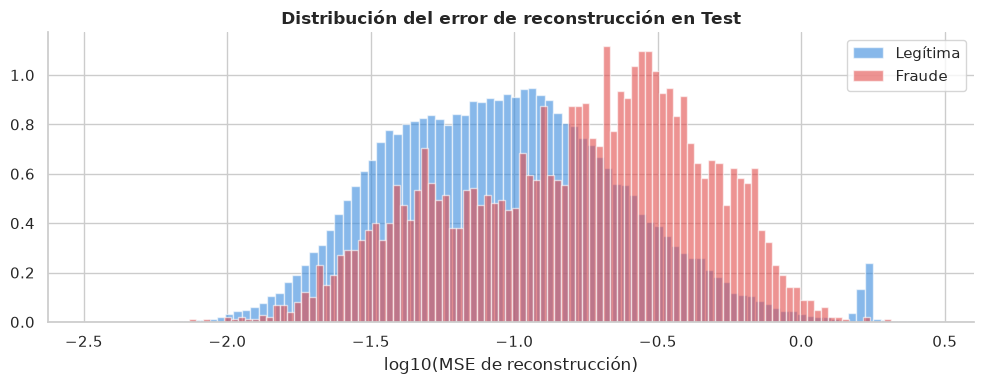

Legítima    0.0895
Fraude      0.1901


In [5]:
error_test = ae.error_reconstruccion(red, Z_test)

fig = plt.figure(figsize=(10, 4))
for clase, color, label in [(0, graficos.AZUL, 'Legítima'), (1, graficos.ROJO, 'Fraude')]:
    plt.hist(np.log10(error_test[y_test == clase]), bins=100, alpha=0.6,
             color=color, label=label, density=True)
plt.title('Distribución del error de reconstrucción en Test')
plt.xlabel('log10(MSE de reconstrucción)')
plt.legend()
sns.despine()
plt.tight_layout()
graficos.guardar(fig, '04_error_clases')
plt.show()

print(pd.Series(error_test).groupby(y_test).median().rename({0: 'Legítima', 1: 'Fraude'}).round(4).to_string())

In [6]:
# ¿Qué transacciones considera más anómalas el autoencoder?
n = int(round(len(y_test) * 0.01))
top_ae = np.argsort(-error_test)[:n]
perfil = df_test.iloc[top_ae]
print(f"1% más anómalo según el autoencoder: {n:,} transacciones, de ellas {y_test[top_ae].sum()} fraudes")

def describir(parte):
    return [
        (parte['ProductCD'] == 'S').mean() * 100,
        (parte['card6'] == 'credit').mean() * 100,
        parte['P_emaildomain'].isna().mean() * 100,
        parte['tx_24h'].median(),
        parte['tx_previas'].median(),
        parte['isFraud'].mean() * 100,
    ]

perfil_top = pd.DataFrame(
    {'Top 1% autoencoder': describir(perfil), 'Todo Test': describir(df_test)},
    index=['% producto S', '% tarjeta de crédito', '% sin dominio de email',
           'Mediana de transacciones en 24 h', 'Mediana de transacciones previas', 'Tasa de fraude (%)'])
print(perfil_top.round(1).to_string())

1% más anómalo según el autoencoder: 1,181 transacciones, de ellas 3 fraudes
                                  Top 1% autoencoder  Todo Test
% producto S                                    92.0        3.0
% tarjeta de crédito                            93.1       23.1
% sin dominio de email                          93.1       17.7
Mediana de transacciones en 24 h               331.0        0.0
Mediana de transacciones previas               823.0        2.0
Tasa de fraude (%)                               0.3        3.4


La mediana del error de reconstrucción de los fraudes (0.1901) es más del doble de la de las transacciones legítimas (0.0895), lo que confirma que el autoencoder, sin haber visto nunca un fraude, sí aprendió que el fraude tiende a alejarse del comportamiento normal, que es el principio de la detección de anomalías por reconstrucción (Sakurada & Yairi, 2014). Sin embargo, las dos distribuciones se superponen en buena parte de su rango y el grupo con el error más alto, el pico de la derecha del gráfico, no es de fraudes.

Este grupo explica el perfil del 1% más anómalo, en el que solo 3 de 1,181 transacciones son fraude (0.3%, por debajo incluso de la tasa de prueba de 3.4%). El 92.0% de ellas son de producto S, el 93.1% con tarjeta de crédito y sin dominio de email, y pertenecen a tarjetas con una mediana de 331 transacciones en las últimas 24 horas, frente a 0 en el total de prueba. Es el mismo tipo de comportamiento que se encontró en la Query 2 del notebook 01, donde las tarjetas de mayor velocidad tenían una tasa de fraude del 0%, por lo que se evidencia que anómalo no es lo mismo que fraudulento.

# Comparación con LightGBM

                      Modelo  ROC-AUC  PR-AUC  GINI
Autoencoder (no supervisado)   0.6680  0.0667 33.60
      LightGBM (supervisado)   0.9085  0.5029 81.69
PR-AUC de un modelo al azar: 0.0344


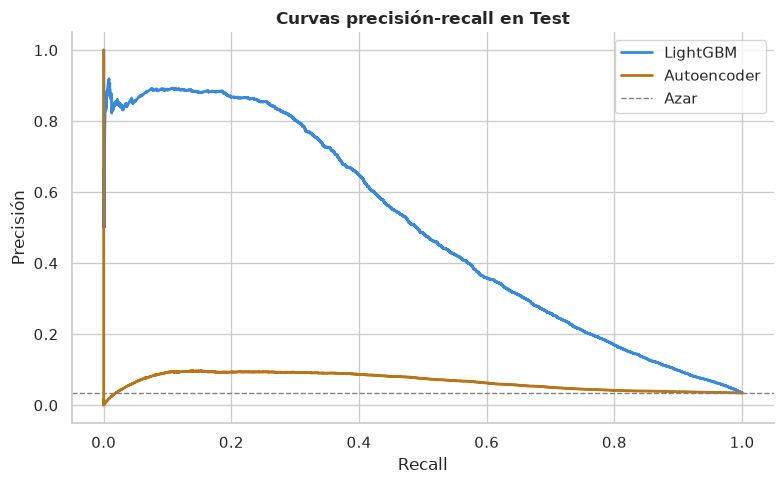

In [7]:
proba_lgbm = paquete['modelo'].predict_proba(X_test_proc)[:, 1]

comparacion = pd.DataFrame([
    {'Modelo': 'Autoencoder (no supervisado)', **modelo.metricas(y_test, error_test)},
    {'Modelo': 'LightGBM (supervisado)', **modelo.metricas(y_test, proba_lgbm)},
])
print(comparacion.to_string(index=False))
print(f"PR-AUC de un modelo al azar: {y_test.mean():.4f}")

fig = plt.figure(figsize=(8, 5))
for puntaje, color, nombre in [(proba_lgbm, graficos.AZUL, 'LightGBM'),
                               (error_test, graficos.OCRE, 'Autoencoder')]:
    precision, recall, _ = precision_recall_curve(y_test, puntaje)
    plt.plot(recall, precision, color=color, lw=2, label=nombre)
plt.axhline(y_test.mean(), color='gray', linestyle='--', lw=1, label='Azar')
plt.title('Curvas precisión-recall en Test')
plt.xlabel('Recall')
plt.ylabel('Precisión')
plt.legend()
sns.despine()
plt.tight_layout()
graficos.guardar(fig, '04_comparacion')
plt.show()

En la comparación directa el autoencoder queda muy por debajo de LightGBM: su PR-AUC de 0.0667 es apenas el doble del de un modelo al azar (0.0344), frente a 0.5029 del modelo supervisado, y su ROC-AUC es de 0.6680 frente a 0.9085. Este resultado es esperable, ya que el autoencoder solo sabe qué es normal y no qué es fraude, mientras que LightGBM aprende directamente de los 16,599 fraudes etiquetados de entrenamiento y validación. Adicionalmente, la curva del autoencoder empieza con una precisión cercana a cero, lo que coincide con lo observado en el error, en el sentido de que sus alertas más seguras son las transacciones legítimas de alto volumen.

# Solapamiento de alertas

In [8]:
# Con el mismo presupuesto de revisión, ¿encuentran los dos modelos los mismos fraudes?

filas = []
for presupuesto in (0.01, 0.05):
    n = int(round(len(y_test) * presupuesto))
    alertas_lgbm = set(np.argsort(-proba_lgbm)[:n])
    alertas_ae = set(np.argsort(-error_test)[:n])
    fraudes = set(np.flatnonzero(y_test == 1))
    filas.append({
        'Revisión': f'{presupuesto*100:.0f}%',
        'Alertas por modelo': n,
        'Fraudes LightGBM': len(alertas_lgbm & fraudes),
        'Fraudes autoencoder': len(alertas_ae & fraudes),
        'En ambos': len(alertas_lgbm & alertas_ae & fraudes),
        'Solo autoencoder': len((alertas_ae - alertas_lgbm) & fraudes),
        'Fraudes en Test': len(fraudes),
    })
solapamiento = pd.DataFrame(filas)
print(solapamiento.to_string(index=False))

Revisión  Alertas por modelo  Fraudes LightGBM  Fraudes autoencoder  En ambos  Solo autoencoder  Fraudes en Test
      1%                1181              1009                    3         0                 3             4064
      5%                5905              2337                  569       387               182             4064


Con un presupuesto del 1%, el autoencoder encuentra solo 3 fraudes frente a 1,009 de LightGBM, por las razones anteriores. Con el 5% la situación cambia, ya que el autoencoder encuentra 569 fraudes, de los cuales 387 también los encuentra LightGBM y 182 solo los detecta el autoencoder. Estos 182 casos son los que justifican un detector no supervisado como complemento, porque corresponden a fraudes que el modelo supervisado no prioriza; sin embargo, para encontrarlos hay que revisar 5,905 alertas del autoencoder con una precisión de 9.6%, por lo que su costo operativo es alto.

# Conclusiones

- El autoencoder entrenado solo con transacciones legítimas asigna a los fraudes un error de reconstrucción mayor (mediana de 0.1901 frente a 0.0895), pero su capacidad de detección es baja (PR-AUC de 0.0667), muy por debajo de LightGBM (0.5029).
- Su principal limitación es que confunde lo raro con lo fraudulento: el 1% de transacciones más anómalas son legítimas de tarjetas de alto volumen, que el modelo supervisado sí sabe distinguir gracias a las etiquetas.
- Como complemento sí tiene valor, ya que con un presupuesto del 5% encuentra 182 fraudes que LightGBM no prioriza. En la práctica, este tipo de detector sirve para vigilar patrones nuevos mientras llegan las etiquetas, que en el fraude con tarjetas pueden tardar semanas (Dal Pozzolo et al., 2018), y no para reemplazar al modelo supervisado.
- Una mejora natural sería entrenar el autoencoder por segmentos, o excluir los segmentos de alto volumen legítimo, para que su error de reconstrucción se concentre en desvíos que sí puedan ser fraude.

## Referencias

- Dal Pozzolo, A., Boracchi, G., Caelen, O., Alippi, C., & Bontempi, G. (2018). Credit card fraud detection: A realistic modeling and a novel learning strategy. *IEEE Transactions on Neural Networks and Learning Systems, 29*(8), 3784–3797. https://doi.org/10.1109/TNNLS.2017.2736643
- Sakurada, M., & Yairi, T. (2014). Anomaly detection using autoencoders with nonlinear dimensionality reduction. En *Proceedings of the MLSDA 2014 2nd Workshop on Machine Learning for Sensory Data Analysis* (pp. 4–11). ACM. https://doi.org/10.1145/2689746.2689747